# Semi-Infinite Biaxial Reflection Coefficient r_pp(k_x, k_y)

**Associated manuscript:** *Spatiotemporal Visualization of Long-Range Anisotropic Plasmon Polaritons in Hyperbolic MoOCl₂*

This notebook computes the polarization-resolved Fresnel reflection coefficient r_pp for a semi-infinite biaxial medium (MoOCl₂) at a vacuum interface, as a function of in-plane wavevector (k_x, k_y). It reproduces:

- **Figure S4** (Supplementary Information): |r_pp(k_x, k_y)| at 1.6 eV for an infinitely thick MoOCl₂ slab.
- Equations S24–S32 in the Supplementary Information.

## Physical background

For a biaxial medium, the standard Fresnel coefficient r_pp = (ε₁k₂z − ε₂k₁z)/(ε₁k₂z + ε₂k₁z) must be generalized to account for the coupling of both extraordinary modes (*a* and *b*) at the interface. The biaxial r_pp (Eq. S24) depends on the polarization mixing coefficients α and β, which describe how the two modes contribute to the reflected field at each propagation angle.

## Table of Contents
1. [Imports and Constants](#1-imports-and-constants)
2. [Dielectric Models and Data](#2-dielectric-models-and-data)
3. [Booker Quartic and Polarization Mixing](#3-booker-quartic-and-polarization-mixing)
4. [Biaxial Reflection Coefficient r_pp](#4-biaxial-reflection-coefficient)
5. [Generate Publication Figure](#5-generate-publication-figure)


## 1. Imports and Constants <a id="1-imports-and-constants"></a>

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
import pandas as pd
from pathlib import Path

# Speed of light in units of eV·μm
C_LIGHT = 0.197

# Default evaluation energy (770 nm = 1.610 eV)
ENERGY_DEFAULT = 1240.0 / 770.0  # eV

# Path to literature dielectric data
DATA_DIR = Path("LiteratureDielectrics")


## 2. Dielectric Models and Data <a id="2-dielectric-models-and-data"></a>

Same dielectric sources as in the Polarization notebook:
- ε_x, ε_y: Melchioni *et al.* (2025) Drude–Lorentz parametrization
- ε_z: Zhao *et al.* (2020) DFT values


In [2]:
# ---------------------------------------------------------------------------
# Helper and dielectric model functions
# ---------------------------------------------------------------------------

def get_nearest_index(arr, val):
    """Return the index of the element in `arr` closest to `val`."""
    return np.argmin(np.abs(arr - val))

sin2 = lambda theta: np.sin(theta)**2
cos2 = lambda theta: np.cos(theta)**2


def drude(omega, omega_p, gamma, eps_inf):
    """Drude dielectric function: ε(ω) = eps_inf − ωp²/[ω(ω + iγ)]"""
    return eps_inf - omega_p**2 / (omega * (omega + 1j * gamma))


def lorentz(omega, f, omega_0, gamma):
    """Lorentzian oscillator: ε(ω) = f²/(ω₀² − ω² − iωγ)"""
    return f**2 / (omega_0**2 - omega**2 - 1j * omega * gamma)


def melchioni_dielectric(energy):
    """MoOCl₂ in-plane dielectric from Melchioni et al. (2025)."""
    eps_x = drude(energy, 5.68, 0.15, 0) + lorentz(energy, 10.04, 4.84, 0.66)
    eps_y = 2.91 + lorentz(energy, 6.48, 3.85, 0.29) + lorentz(energy, 0.78, 1.17, 0.44)
    return eps_x, eps_y


def import_csv_dielectric(filepath, energy_grid):
    """Import dielectric component from CSV and interpolate onto energy_grid."""
    df = pd.read_csv(filepath, header=None)
    return np.interp(energy_grid, np.asarray(df[0]), np.asarray(df[1]))


In [3]:
# ---------------------------------------------------------------------------
# Load dielectric data
# ---------------------------------------------------------------------------
E0 = np.linspace(1, 4, 250)

melchioni_x, melchioni_y = melchioni_dielectric(E0)

moocl2_dir = DATA_DIR / "MoOCl2"
z_dft = (import_csv_dielectric(moocl2_dir / "Re Z.csv", E0)
         + 1j * import_csv_dielectric(moocl2_dir / "Im Z.csv", E0))

ind = get_nearest_index(E0, ENERGY_DEFAULT)
print(f"At {ENERGY_DEFAULT:.3f} eV:")
print(f"  ε_x = {melchioni_x[ind]:.4f}")
print(f"  ε_y = {melchioni_y[ind]:.4f}")
print(f"  ε_z = {z_dft[ind]:.4f}")


At 1.610 eV:
  ε_x = -7.4427+1.3873j
  ε_y = 5.9725+0.3438j
  ε_z = 3.7674+1.1315j


## 3. Booker Quartic and Polarization Mixing <a id="3-booker-quartic-and-polarization-mixing"></a>

We need k_z for both extraordinary modes and the polarization mixing coefficients α(k_x, k_y; ω) and β(k_x, k_y; ω), which describe how the E-field of each mode couples to the other polarization direction (Eqs. S13 and S17 in the Supplement).

Since this notebook computes r_pp for a *lossy* material (complex dielectric), we use a simplified branch selection appropriate for the semi-infinite case.


In [4]:
def kz_biaxial_lossy(omega, k_mag, phi, eps_x, eps_y, eps_z, mode="a"):
    """
    Solve the Booker quartic for k_z in a biaxial medium with complex ε.
    
    Simplified branch selection for lossy media (Im(ε) ≠ 0), appropriate
    for the semi-infinite reflection coefficient calculation.
    
    Parameters
    ----------
    omega : float
        Photon energy (eV).
    k_mag : float
        In-plane wavevector magnitude (μm⁻¹).
    phi : float
        Propagation angle from a-axis (radians).
    eps_x, eps_y, eps_z : complex
        Dielectric tensor components.
    mode : str
        'a' or 'b'.
    
    Returns
    -------
    complex : k_z for the selected mode.
    """
    eps_xx = eps_x * cos2(phi) + eps_y * sin2(phi)
    eps_yy = eps_x * sin2(phi) + eps_y * cos2(phi)
    eps_xy = (eps_y - eps_x) * np.cos(phi) * np.sin(phi)
    
    k0 = omega / C_LIGHT
    
    b = k_mag**2 * (eps_xx + eps_z) - eps_z * (eps_xx + eps_yy) * k0**2
    c1 = ((eps_z * k0**2 - k_mag**2) *
          (eps_xx * eps_yy * k0**2 - eps_xx * k_mag**2 - k0**2 * eps_xy**2))
    
    discriminant = b**2 - 4 * eps_z * c1
    sqrt_disc = np.emath.sqrt(discriminant)
    
    # Branch selection for lossy media based on discriminant phase
    if discriminant.imag >= 0:
        sqrt_a = -sqrt_disc
        sqrt_b = sqrt_disc
    else:
        sqrt_a = sqrt_disc
        sqrt_b = -sqrt_disc
    
    kz_a = np.emath.sqrt((-b + sqrt_a) / (2 * eps_z))
    kz_b = np.emath.sqrt((-b + sqrt_b) / (2 * eps_z))
    
    # Ensure Im(kz) > 0 for decaying waves
    if kz_a.imag < 0: kz_a = -kz_a
    if kz_b.imag < 0: kz_b = -kz_b
    
    return kz_a if mode == "a" else kz_b


In [5]:
def alpha_mixing(omega, k_mag, phi, eps_x, eps_y, eps_z):
    """
    Polarization mixing coefficient α = E_y/E_x for the a-mode (Eq. S13).
    
    With E_x = 1 for the a-mode, α gives the y-component of the E-field.
    """
    kz = kz_biaxial_lossy(omega, k_mag, phi, eps_x, eps_y, eps_z, mode="a")
    kx = k_mag * np.cos(phi)
    ky = k_mag * np.sin(phi)
    k0 = omega / C_LIGHT
    
    del_y = eps_y * k0**2 - kx**2 - kz**2
    del_z = eps_z * k0**2 - kx**2 - ky**2
    
    Ez = kx * kz * (del_y - ky**2) / (ky**2 * kz**2 - del_y * del_z)
    Ey = -ky * (kz * Ez + kx) / del_y
    return Ey  # α = Ey/Ex with Ex = 1


def beta_mixing(omega, k_mag, phi, eps_x, eps_y, eps_z):
    """
    Polarization mixing coefficient β = E_x/E_y for the b-mode (Eq. S17).
    
    With E_y = 1 for the b-mode, β gives the x-component of the E-field.
    """
    kz = kz_biaxial_lossy(omega, k_mag, phi, eps_x, eps_y, eps_z, mode="b")
    kx = k_mag * np.cos(phi)
    ky = k_mag * np.sin(phi)
    k0 = omega / C_LIGHT
    
    del_x = eps_x * k0**2 - ky**2 - kz**2
    del_z = eps_z * k0**2 - kx**2 - ky**2
    
    Ez = ky * kz * (del_x - kx**2) / (kx**2 * kz**2 - del_x * del_z)
    Ex = -kx * (kz * Ez + ky) / del_x
    return Ex  # β = Ex/Ey with Ey = 1


## 4. Biaxial Reflection Coefficient r_pp <a id="4-biaxial-reflection-coefficient"></a>

The p-polarized reflection coefficient for a vacuum/biaxial interface at arbitrary propagation angle φ is given by Eq. S24 of the Supplement:

$$r_{pp} = \frac{A_1 B_2 k_{bz}(k_{1z}+k_{bz})(\varepsilon_1 k_{az} - \varepsilon_{xx} k_{1z}) - A_2 B_1 k_{az}(k_{1z}+k_{az})(\varepsilon_1 k_{bz} - \varepsilon_{xx} k_{1z})}{A_1 B_2 k_{bz}(k_{1z}+k_{bz})(\varepsilon_1 k_{az} + \varepsilon_{xx} k_{1z}) - A_2 B_1 k_{az}(k_{1z}+k_{az})(\varepsilon_1 k_{bz} + \varepsilon_{xx} k_{1z})}$$

where A₁, B₁, A₂, B₂ are defined in Eqs. S25–S28 via the mixing coefficients α and β in Eqs. S13 and S17 from the Booker quartic.


In [6]:
def r_pp_biaxial(omega, k_mag, phi, eps1, eps_x, eps_y, eps_z):
    """
    Biaxial Fresnel reflection coefficient r_pp for a vacuum/biaxial interface.
    
    Implements Eq. S24 of the Supplementary Information.
    
    Parameters
    ----------
    omega : float
        Photon energy (eV).
    k_mag : float
        In-plane wavevector magnitude (μm⁻¹).
    phi : float
        Propagation angle from a-axis (radians).
    eps1 : complex
        Dielectric of medium 1 (vacuum = 1).
    eps_x, eps_y, eps_z : complex
        Biaxial dielectric tensor of medium 2.
    
    Returns
    -------
    r_re, r_im : float
        Real and imaginary parts of r_pp.
    
    Notes
    -----
    At φ = 0 this reduces to r_pp = (ε₁k_az − ε_x k₁z)/(ε₁k_az + ε_x k₁z) (Eq. S30).
    At φ = π/2 it reduces to r_pp = (ε₁k_bz − ε_y k₁z)/(ε₁k_bz + ε_y k₁z) (Eq. S31).
    """
    # Rotated in-plane dielectric (Eq. S29)
    eps_xx = eps_x * cos2(phi) + eps_y * sin2(phi)
    
    # k_z for both modes and vacuum
    k_az = kz_biaxial_lossy(omega, k_mag, phi, eps_x, eps_y, eps_z, mode="a")
    k_bz = kz_biaxial_lossy(omega, k_mag, phi, eps_x, eps_y, eps_z, mode="b")
    
    k0 = omega / C_LIGHT
    k1z = np.emath.sqrt(k0**2 * eps1 - k_mag**2)
    if k1z.imag < 0:
        k1z = -k1z
    
    # Polarization mixing coefficients (Eqs. S25–S28)
    alpha0 = alpha_mixing(omega, k_mag, phi, eps_x, eps_y, eps_z)
    beta0 = beta_mixing(omega, k_mag, phi, eps_x, eps_y, eps_z)
    
    A1 = np.cos(phi) + alpha0 * np.sin(phi)
    B2 = np.cos(phi) - beta0 * np.sin(phi)
    A2 = alpha0 * np.cos(phi) - np.sin(phi)
    B1 = beta0 * np.cos(phi) + np.sin(phi)
    
    # Numerator and denominator of Eq. S24
    term1 = A1 * B2 * k_bz * (k1z + k_bz) * (eps1 * k_az - eps_xx * k1z)
    term2 = A2 * B1 * k_az * (k1z + k_az) * (eps1 * k_bz - eps_xx * k1z)
    term3 = A1 * B2 * k_bz * (k1z + k_bz) * (eps1 * k_az + eps_xx * k1z)
    term4 = A2 * B1 * k_az * (k1z + k_az) * (eps1 * k_bz + eps_xx * k1z)
    
    rpp = (term1 - term2) / (term3 - term4)
    return rpp.real, rpp.imag


def compute_rpp_map(omega, kx_arr, eps1, eps_x, eps_y, eps_z, return_type='abs'):
    """
    Compute r_pp on a 2D (kx, ky) grid for a semi-infinite biaxial medium.
    
    Parameters
    ----------
    omega : float
        Photon energy (eV).
    kx_arr : array_like
        1D array used for both kx and ky axes (μm⁻¹).
    eps1 : complex
        Upper medium dielectric.
    eps_x, eps_y, eps_z : complex
        Biaxial dielectric tensor.
    return_type : str
        'abs' for |r_pp|, 'im' for |Im(r_pp)|, 'phase' for arg(r_pp).
    
    Returns
    -------
    2D array of the selected quantity on the (ky, kx) grid.
    """
    n = len(kx_arr)
    result = np.zeros((n, n))
    
    for i, kx in enumerate(kx_arr):
        for j, ky in enumerate(kx_arr):
            phi = np.arctan2(ky, kx)
            k = np.sqrt(kx**2 + ky**2)
            r_re, r_im = r_pp_biaxial(omega, k, phi, eps1, eps_x, eps_y, eps_z)
            
            if return_type == 'abs':
                result[j, i] = np.sqrt(r_re**2 + r_im**2)
            elif return_type == 'im':
                result[j, i] = np.abs(r_im)
            elif return_type == 'phase':
                result[j, i] = np.arctan2(r_im, r_re)
    
    return result


## 5. Generate Publication Figure <a id="5-generate-publication-figure"></a>

Absolute value of r_pp(k_x, k_y) at 1.6 eV for an infinitely thick MoOCl₂ sample at the vacuum interface (**Figure S4** of the Supplementary Information).


In [7]:
# ---------------------------------------------------------------------------
# Compute |r_pp| map at 770 nm
# ---------------------------------------------------------------------------
kx = np.linspace(-30, 30, 250)
ind = get_nearest_index(E0, ENERGY_DEFAULT)

epsx = melchioni_x[ind]
epsy = melchioni_y[ind]
epsz = z_dft[ind]

print(f"Computing |r_pp(kx, ky)| at {ENERGY_DEFAULT:.3f} eV...")
print(f"  Grid: {len(kx)}×{len(kx)} points")
rpp_abs = compute_rpp_map(ENERGY_DEFAULT, kx, 1.0, epsx, epsy, epsz, return_type='abs')
print("Done.")


Computing |r_pp(kx, ky)| at 1.610 eV...
  Grid: 250×250 points
Done.


C:\Users\sbking\AppData\Local\Temp\ipykernel_57836\2673065844.py:8: RuntimeWarning: invalid value encountered in sqrt
  light_line = np.sqrt(k0**2 - kx_ref**2)
c:\Users\sbking\AppData\Local\anaconda3\lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\sbking\AppData\Local\anaconda3\lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


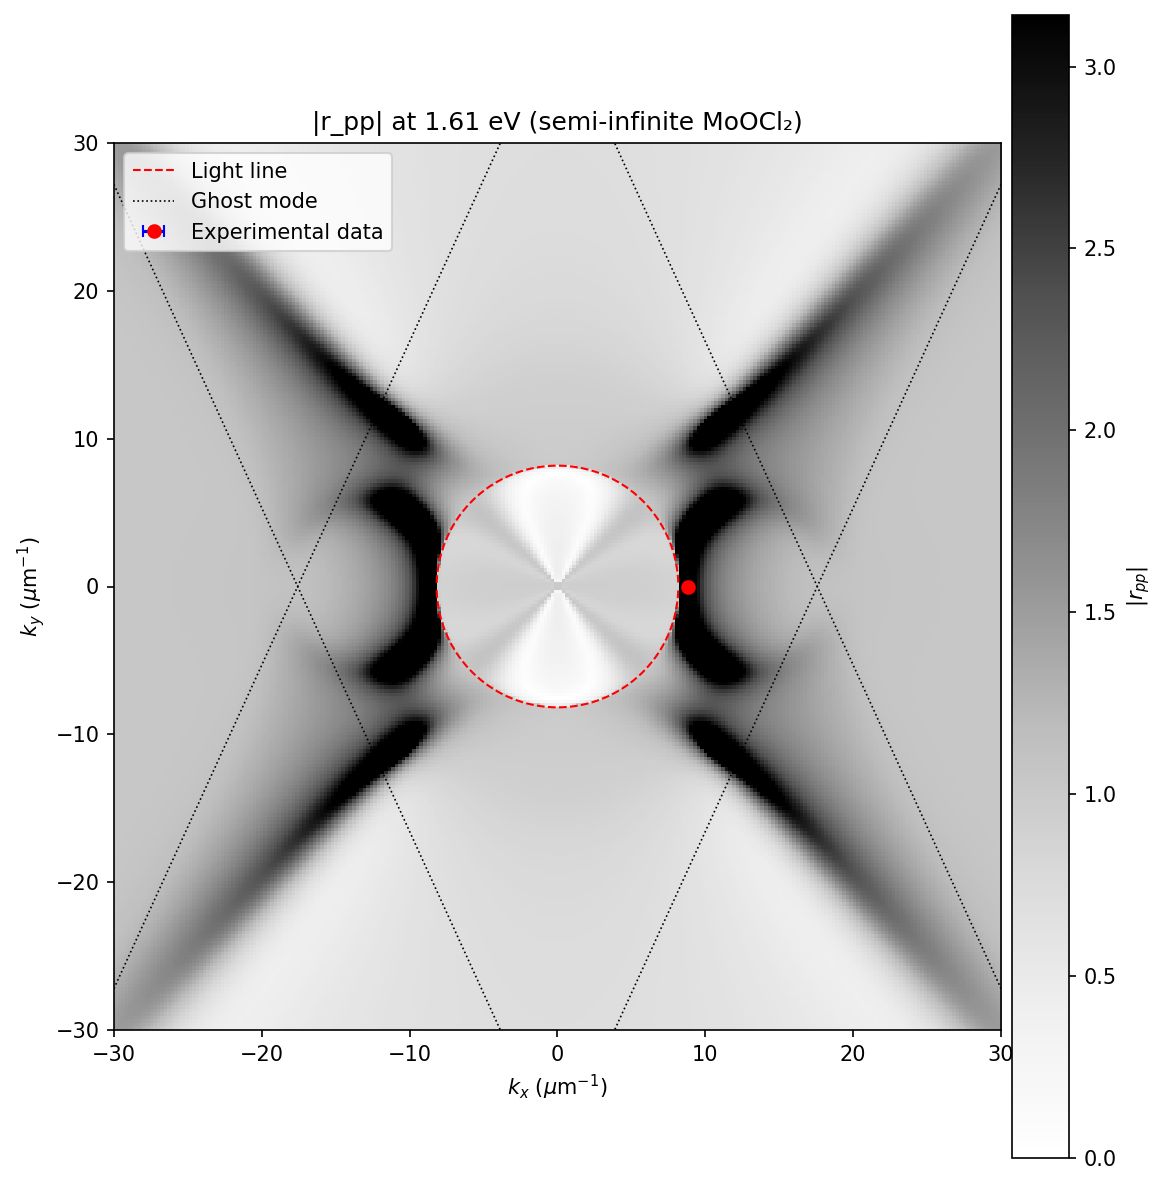

In [8]:
# ---------------------------------------------------------------------------
# Plot |r_pp| (Figure S4)
# ---------------------------------------------------------------------------

# Reference curves
kx_ref = np.linspace(-30, 30, 3500)
k0 = ENERGY_DEFAULT / C_LIGHT
light_line = np.sqrt(k0**2 - kx_ref**2)

A = np.sqrt(np.abs(epsx - epsz) / epsz)
B = np.sqrt(np.abs(epsy - epsz) / epsz)
C_ghost = np.sqrt(np.abs(epsx - epsy)) * k0

# Experimental data point at 770 nm
exp_kx = 8.808
exp_err = 0.215

fig, ax = plt.subplots(figsize=(8, 8), dpi=150)
im = ax.imshow(rpp_abs, cmap=cm.Greys, aspect='equal',
               extent=[kx[0], kx[-1], kx[0], kx[-1]],
               vmin=0, vmax=np.pi, origin='lower')

# Light line
ax.plot(kx_ref, light_line, 'r--', lw=1, label='Light line')
ax.plot(kx_ref, -light_line, 'r--', lw=1)

# Ghost mode boundaries
ax.plot(kx_ref, (C_ghost/B + kx_ref*A/B), 'k:', lw=0.8, label='Ghost mode')
ax.plot(kx_ref, (-C_ghost/B - kx_ref*A/B), 'k:', lw=0.8)
ax.plot(kx_ref, (-C_ghost/B + kx_ref*A/B), 'k:', lw=0.8)
ax.plot(kx_ref, (C_ghost/B - kx_ref*A/B), 'k:', lw=0.8)

# Experimental point
ax.errorbar(exp_kx, 0, xerr=exp_err, fmt='o', color='red', ecolor='blue',
            capsize=3, label='Experimental data')

ax.set_xlim([kx[0], kx[-1]])
ax.set_ylim([kx[0], kx[-1]])
ax.set_xlabel(r"$k_x$ ($\mu$m$^{-1}$)")
ax.set_ylabel(r"$k_y$ ($\mu$m$^{-1}$)")
ax.set_title(f"|r_pp| at {ENERGY_DEFAULT:.2f} eV (semi-infinite MoOCl₂)")
plt.colorbar(im, ax=ax, pad=0.01, label=r'$|r_{pp}|$')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig("rpp_xy.eps", format='eps', bbox_inches='tight', dpi=500)
plt.show()
